# 04 — Reportes y Evaluación Experimental `obra_v4`

## Sistema de Detección de Riesgos de Corrupción en Obras Públicas

Este notebook consolida los resultados experimentales obtenidos en los notebooks:

- `01_eda_diccionarios.ipynb`
- `02_build_dataset_obra_v4_features_maestro.ipynb`
- `03_train_obra_v4.ipynb`

Su propósito es generar reportes técnicos, métricas, visualizaciones y artefactos de evaluación del baseline actual del sistema.

---

# Objetivos

- Consolidar métricas experimentales.
- Generar reportes de desempeño.
- Visualizar comportamiento del modelo.
- Analizar importancia de variables.
- Evaluar estabilidad experimental.
- Generar artefactos exportables.


In [1]:
# Librerías principales

import pandas as pd
import numpy as np
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

import joblib


# Configuración de Rutas

Se tiene la siguiente estructura:

```text
DETECCION_CORRUPCION/
│
├── data/
├── models/
├── notebooks/
└── reports/
```


In [3]:
# Configuración de rutas

BASE_DIR = Path("..")

DATASET_PATH = BASE_DIR / "data" / "processed" / "dataset_obra_v4_model.parquet"

MODEL_DIR = BASE_DIR / "models" / "obra_v4"

PIPELINE_PATH = MODEL_DIR / "pipeline_rf_obra_v4.pkl"
METRICS_PATH = MODEL_DIR / "metrics_rf_obra_v4.json"
FEATURES_PATH = MODEL_DIR / "feature_importance_rf_obra_v4.csv"

REPORT_DIR = BASE_DIR / "reports" / "obra_v4"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuración completada")
print(f"Dataset path: {DATASET_PATH}")
print(f"Pipeline path: {PIPELINE_PATH}")
print(f"Metrics path: {METRICS_PATH}")
print(f"Features path: {FEATURES_PATH}")


Configuración completada
Dataset path: ..\data\processed\dataset_obra_v4_model.parquet
Pipeline path: ..\models\obra_v4\pipeline_rf_obra_v4.pkl
Metrics path: ..\models\obra_v4\metrics_rf_obra_v4.json
Features path: ..\models\obra_v4\feature_importance_rf_obra_v4.csv


# Carga del Dataset

In [4]:
# Carga de dataset

try:
    df = pd.read_parquet(DATASET_PATH)
    print("Dataset cargado correctamente")
    print(df.shape)
except Exception as e:
    print(f"Error cargando dataset: {e}")


Dataset cargado correctamente
(326, 79)


# Vista General del Dataset

In [5]:
# Vista general

df.head()


,IDENTIFICADOR_OBRA,ETAPA,DIAS_PLAZO,TOTAL_CONTROL_PREVIO,TOTAL_CONTROL_SIMULTANEO,TOTAL_CONTROL_POSTERIOR,y_riesgo_obra,obra_ctx_sector,obra_ctx_nivel_gobierno,obra_ctx_objeto_proceso,...,obra_sobreavance,obra_n_alertas_total,obra_n_filas_con_alerta,obra_pct_filas_con_alerta,obra_tiene_ejecutora,obra_tiene_supervisora,obra_paralizada,obra_inactiva,obra_en_ejecucion,obra_finalizada
0,2002060-2434-702592-2064311-19777,ESTUDIO DEFINITIVO,0,0,0,0,3,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,...,0,0,0,0.0,0,0,0,0,0,1
1,2002210-8880-869397-2169938-826,ETAPA NO IDENTIFICADA,0,0,0,0,2,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,...,0,0,0,0.0,0,0,0,0,1,0
2,2002210-8880-870112-2169901-826,ETAPA NO IDENTIFICADA,0,0,0,0,2,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,...,0,0,0,0.0,0,0,0,0,1,0
3,2015918-1249-721938-2074791-45660,ESTUDIO DEFINITIVO,0,0,0,0,3,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,...,0,1,1,1.0,0,0,0,0,0,1
4,2026767-16256-709096-2067605-143536,EXPEDIENTE TÉCNICO,0,0,0,0,3,TRANSPORTE,GOBIERNO NACIONAL,Consultoría de Obra,...,0,0,0,0.0,0,0,0,0,0,0


In [6]:
# Información general

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 79 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   IDENTIFICADOR_OBRA                  326 non-null    object 
 1   ETAPA                               326 non-null    object 
 2   DIAS_PLAZO                          326 non-null    int64  
 3   TOTAL_CONTROL_PREVIO                326 non-null    int64  
 4   TOTAL_CONTROL_SIMULTANEO            326 non-null    int64  
 5   TOTAL_CONTROL_POSTERIOR             326 non-null    int64  
 6   y_riesgo_obra                       326 non-null    int64  
 7   obra_ctx_sector                     326 non-null    object 
 8   obra_ctx_nivel_gobierno             326 non-null    object 
 9   obra_ctx_objeto_proceso             326 non-null    object 
 10  obra_ctx_metodo_contratacion        326 non-null    object 
 11  obra_ctx_departamento               326 non-n

# Distribución del Target

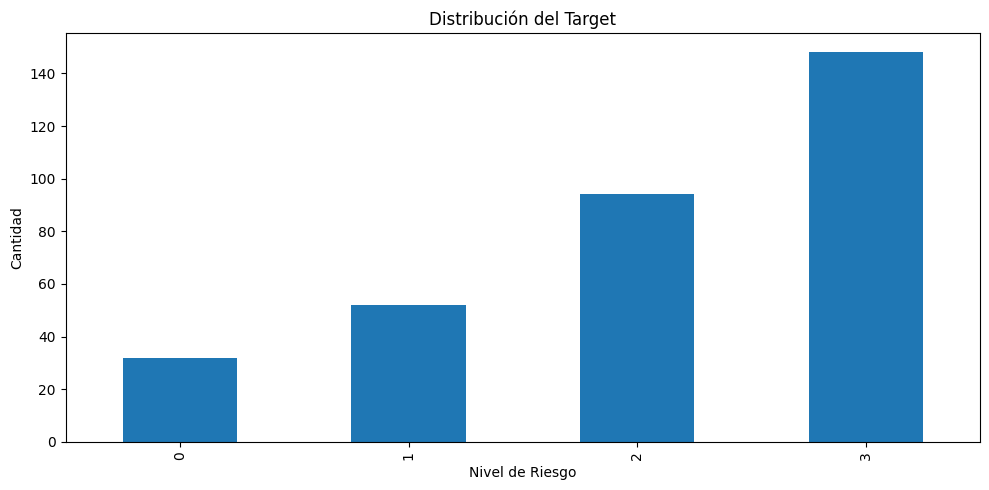

In [10]:
TARGET = "y_riesgo_obra"

if TARGET in df.columns:
    plt.figure(figsize=(10,5))
    df[TARGET].value_counts().sort_index().plot(kind="bar")
    plt.title("Distribución del Target")
    plt.xlabel("Nivel de Riesgo")
    plt.ylabel("Cantidad")
    plt.tight_layout()
    plt.show()


# Carga del Modelo Baseline

In [11]:
# Carga del modelo

try:
    pipeline = joblib.load(PIPELINE_PATH)
    print("Modelo cargado correctamente")
except Exception as e:
    print(f"Error cargando modelo: {e}")


Modelo cargado correctamente


# Métricas Exportadas

In [12]:
# Lectura de métricas

try:
    with open(METRICS_PATH, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    metrics_df = pd.DataFrame([metrics])
    display(metrics_df)

except Exception as e:
    print(f"Error leyendo métricas: {e}")


,model_name,dataset,target_strategy,n_features,n_train,n_test,accuracy,balanced_accuracy,macro_f1,weighted_f1,cv_macro_f1_mean,best_params,class_labels
0,RandomForest_obra_v4_tuned,obra_v4_4niveles,4 niveles (Decisión D1),77,260,66,0.666667,0.558094,0.580392,0.643078,0.590122,"{'model__bootstrap': False, 'model__max_depth'...","[Sin Riesgo, Bajamente Riesgosa, Med/Alt Riesg..."


# Feature Importance

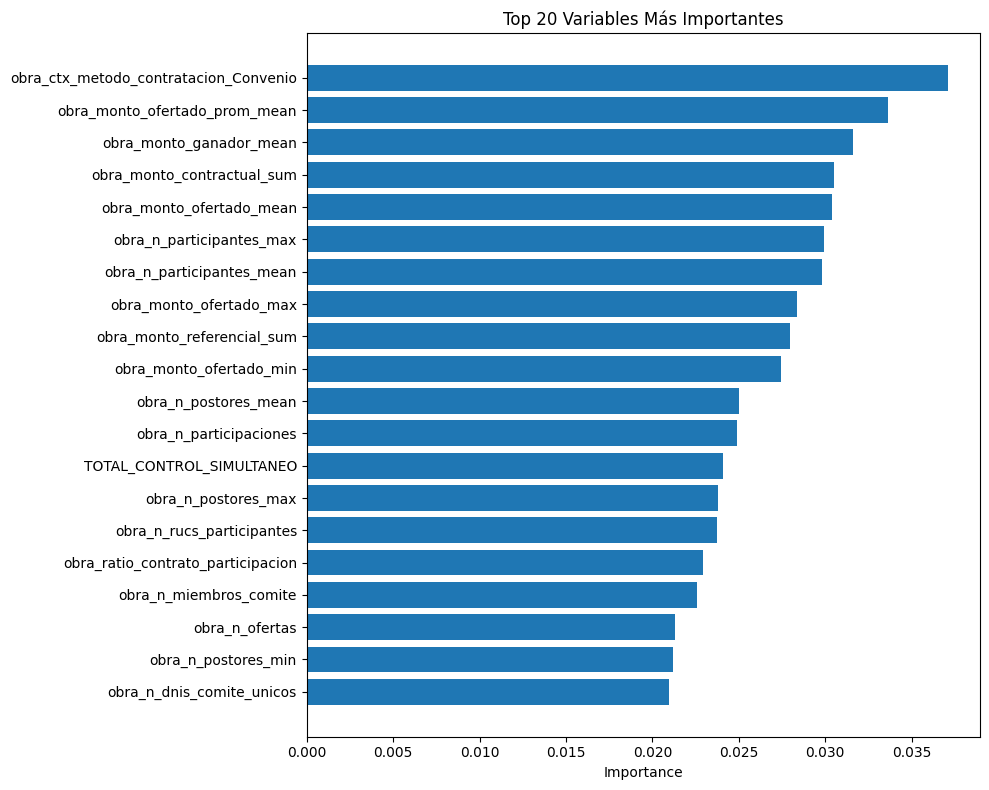

In [13]:
# Importancia de variables

try:
    fi = pd.read_csv(FEATURES_PATH)

    fi = fi.sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10,8))
    plt.barh(fi["feature"], fi["importance"])
    plt.gca().invert_yaxis()

    plt.title("Top 20 Variables Más Importantes")
    plt.xlabel("Importance")

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error leyendo feature importance: {e}")


# Validaciones Metodológicas

Durante el desarrollo experimental se identificaron y mitigaron riesgos relacionados con:

- data leakage
- variables derivadas del target
- contaminación entre train y test
- sobreajuste
- granularidad inconsistente
- variables redundantes


# Hallazgos Relevantes

Las variables con mayor impacto experimental estuvieron asociadas a:

- montos ofertados
- variabilidad económica
- patrones de comité
- comportamiento contractual
- cantidad de participantes
- señales de concentración
- ejecución de obra


# Próximas Mejoras

## Explainability

- SHAP
- LIME
- explicaciones locales

## Modelos

- XGBoost
- LightGBM
- CatBoost

## Analítica avanzada

- detección de redes
- scoring institucional
- análisis relacional


# Conclusiones

El baseline `obra_v4` constituye actualmente la línea base experimental del sistema de detección de riesgos de corrupción.

Los resultados obtenidos validan la viabilidad de aplicar técnicas de Machine Learning en contextos de control gubernamental y priorización de riesgos.
